In [65]:
import numpy as np
import glob
import os

data_dir = '/Users/muhammad/Desktop/Generated_Embeddings/Class_Conditing/NF-UNSW-NB15-v2/class_conditioned_embeddings/'
 
 

embedding_files = sorted(glob.glob(os.path.join(data_dir, 'train_embeddings_batch*.npy')))
label_files = sorted(glob.glob(os.path.join(data_dir, 'train_labels_batch*.npy')))

print(embedding_files)

# Load and stack embeddings
embedding_batches = [np.load(f,allow_pickle=True)for f in embedding_files]  # list of (60000, 512) or (batch, 60000, 512)
# If shape is (31, 60000, 512) per file, flatten each
embedding_batches = [e.reshape(-1, e.shape[-1]) for e in embedding_batches]
x_train = np.concatenate(embedding_batches, axis=0)

# Load and stack labels
label_batches = [np.load(f,allow_pickle=True) for f in label_files]
y_train = np.concatenate([l.reshape(-1) for l in label_batches], axis=0)

['/Users/muhammad/Desktop/Generated_Embeddings/Class_Conditing/NF-UNSW-NB15-v2/class_conditioned_embeddings/train_embeddings_batch0.npy', '/Users/muhammad/Desktop/Generated_Embeddings/Class_Conditing/NF-UNSW-NB15-v2/class_conditioned_embeddings/train_embeddings_batch1.npy', '/Users/muhammad/Desktop/Generated_Embeddings/Class_Conditing/NF-UNSW-NB15-v2/class_conditioned_embeddings/train_embeddings_batch10.npy', '/Users/muhammad/Desktop/Generated_Embeddings/Class_Conditing/NF-UNSW-NB15-v2/class_conditioned_embeddings/train_embeddings_batch11.npy', '/Users/muhammad/Desktop/Generated_Embeddings/Class_Conditing/NF-UNSW-NB15-v2/class_conditioned_embeddings/train_embeddings_batch12.npy', '/Users/muhammad/Desktop/Generated_Embeddings/Class_Conditing/NF-UNSW-NB15-v2/class_conditioned_embeddings/train_embeddings_batch13.npy', '/Users/muhammad/Desktop/Generated_Embeddings/Class_Conditing/NF-UNSW-NB15-v2/class_conditioned_embeddings/train_embeddings_batch14.npy', '/Users/muhammad/Desktop/Generated_

In [24]:
x_train.head()  # Display the first few rows of the training data

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [94]:
import numpy as np
import pandas as pd
import glob
import os

# Path to the embeddings folder
data_dir = '/Users/muhammad/Desktop/Generated_Embeddings/Class_Conditing/NF-CSE-CIC-IDS2018-v2/class_conditioned_embeddings/'

def load_and_stack(embedding_pattern, label_pattern):
    embedding_files = sorted(glob.glob(os.path.join(data_dir, embedding_pattern)))
    label_files = sorted(glob.glob(os.path.join(data_dir, label_pattern)))
    
    embeddings_list = []
    labels_list = []

    for embed_file, label_file in zip(embedding_files, label_files):
        embeddings = np.load(embed_file, allow_pickle=True)
        labels = np.load(label_file, allow_pickle=True)

        embeddings_list.append(embeddings)
        labels_list.append(labels)

        print(f"Loaded {os.path.basename(embed_file)} ({embeddings.shape}) and {os.path.basename(label_file)} ({labels.shape})")

    # Stack all together
    X = np.vstack(embeddings_list)
    y = np.concatenate(labels_list)

    # Convert to DataFrames (optional)
    X_df = pd.DataFrame(X)
    y_df = pd.Series(y, name='label')

    return X_df, y_df

# Load train and test sets separately
X_train, y_train = load_and_stack("train_embeddings_batch*.npy", "train_labels_batch*.npy")
X_test, y_test = load_and_stack("test_embeddings_batch*.npy", "test_labels_batch*.npy")

print("\nTrain shape:", X_train.shape, "| Labels:", y_train.shape)
print("Test shape:", X_test.shape, "| Labels:", y_test.shape)


Loaded train_embeddings_batch0.npy ((48000, 64)) and train_labels_batch0.npy ((48000,))
Loaded train_embeddings_batch1.npy ((48000, 64)) and train_labels_batch1.npy ((48000,))
Loaded train_embeddings_batch10.npy ((48000, 64)) and train_labels_batch10.npy ((48000,))
Loaded train_embeddings_batch11.npy ((48000, 64)) and train_labels_batch11.npy ((48000,))
Loaded train_embeddings_batch2.npy ((48000, 64)) and train_labels_batch2.npy ((48000,))
Loaded train_embeddings_batch3.npy ((48000, 64)) and train_labels_batch3.npy ((48000,))
Loaded train_embeddings_batch4.npy ((48000, 64)) and train_labels_batch4.npy ((48000,))
Loaded train_embeddings_batch5.npy ((48000, 64)) and train_labels_batch5.npy ((48000,))
Loaded train_embeddings_batch6.npy ((48000, 64)) and train_labels_batch6.npy ((48000,))
Loaded train_embeddings_batch7.npy ((48000, 64)) and train_labels_batch7.npy ((48000,))
Loaded train_embeddings_batch8.npy ((48000, 64)) and train_labels_batch8.npy ((48000,))
Loaded train_embeddings_batc

In [95]:
X_train.shape


(576000, 64)

In [96]:
y_train.shape

(576000,)

In [97]:
mask = ~np.isnan(X_train).any(axis=1)

# Filter x_train and y_train with the mask
x_train_cleaned = X_train[mask]
y_train_cleaned = y_train[mask]

In [98]:
y_train_cleaned

144000              Benign
144001              Benign
144002    DDOS attack-HOIC
144003              Benign
144004                 Bot
                ...       
575995       Infilteration
575996              Benign
575997              Benign
575998              Benign
575999              Benign
Name: label, Length: 288000, dtype: object

In [99]:
unique_labels, counts = np.unique(y_train_cleaned, return_counts=True)
unique_labels

array(['Benign', 'Bot', 'Brute Force -Web', 'Brute Force -XSS',
       'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP',
       'DDoS attacks-LOIC-HTTP', 'DoS attacks-GoldenEye',
       'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest',
       'DoS attacks-Slowloris', 'FTP-BruteForce', 'Infilteration',
       'SQL Injection', 'SSH-Bruteforce'], dtype=object)

In [100]:
binary_arr = np.where(y_train_cleaned == 'Benign', 0, 1)
unique_labels, counts = np.unique(binary_arr, return_counts=True)
binary_arr.shape

(288000,)

In [101]:
unique_labels, counts = np.unique(binary_arr, return_counts=True)
unique_labels

array([0, 1])

In [102]:

binary_arr.shape

(288000,)

In [103]:
unique_labels.shape

(2,)

In [104]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# embeddings = X_train[0]  # Now shape: (N, D)

# label_encoder = LabelEncoder()
# labels_encoded = label_encoder.fit_transform(labels)

# Sanity check
# assert embeddings.shape[0] == labels.shape[0], "Mismatch between embeddings and labels"

# Step 3: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    x_train_cleaned, binary_arr, test_size=0.1, random_state=42, stratify=binary_arr
)

# Step 4: Save to .npz
np.savez('CC_data_NF-CSE-CIC-IDS2018-v2.npz', X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)


# Optional: Verify
# print("Saved data.npz with:", np.load('custom_data_NF-CSE-CIC-IDS2018-v2.npz').files)

In [175]:
import numpy as np
data= np.load('Auto_embedding/netflow_autoencoder_repr_NF-CSE-CIC-IDS2018-v2.npz',allow_pickle=True)



In [180]:
X_train=data['X_test'].astype(np.float32)
X_train.shape


(15114966, 64)

In [181]:
y_train=data['y_train']
y_train.shape

(15114966,)

In [178]:
mask = ~pd.isna(y_train)               # returns a NumPy bool array
X_train = X_train.loc[mask] if hasattr(X_train, "loc") else X_train[mask]
y_train = np.asarray(y_train[mask], dtype=np.int32)

In [182]:
# If y_train is a NumPy array:
unique, counts = np.unique(y_train, return_counts=True)

# Combine and print as a dictionary
print(dict(zip(unique, counts)))

TypeError: boolean value of NA is ambiguous

In [141]:
unique_labels, counts = np.unique(unique, return_counts=True)
unique_labels

array([0, 1, 2], dtype=object)

In [107]:
# If y_train is a NumPy array:
unique, counts = np.unique(y_train, return_counts=True)

# Combine and print as a dictionary
# counts
unique
# ts

array([0, 1])

In [108]:
unique_labels, counts = np.unique(y_train, return_counts=True)
counts



array([87819,   181])

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

kmeans = KMeans(n_clusters=2).fit(data['X_train'])
labels = kmeans.labels_

sil_score = silhouette_score(data['X_train'], labels)
db_score = davies_bouldin_score(data['X_train'], labels)


KeyboardInterrupt: 

In [37]:
data = np.load('custom_data.npz')
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

In [40]:
X_train

array([[-4.24708271e+00, -2.86543250e+00,  4.28940535e-01, ...,
        -6.44291472e-03, -6.15876028e-03, -2.45736912e-03],
       [-4.71049881e+00, -1.39133632e+00,  6.11438870e-01, ...,
         9.77301747e-02, -6.38771132e-02,  2.19721626e-03],
       [-4.70219803e+00, -2.78380245e-01,  1.32432103e+00, ...,
        -3.05691436e-02,  4.06620763e-02, -1.14154756e-01],
       ...,
       [-4.29130793e+00, -2.85115457e+00,  4.42537487e-01, ...,
         1.40840197e-02,  2.44468283e-02, -2.25587320e-02],
       [ 1.77728975e+00,  2.25561306e-01, -5.31232023e+00, ...,
         2.15128791e-02,  2.31974237e-02,  5.85834170e-03],
       [-4.85936832e+00, -4.71968621e-01,  1.49919927e+00, ...,
        -1.85027402e-02,  2.36414596e-02,  1.91648472e-02]], dtype=float32)

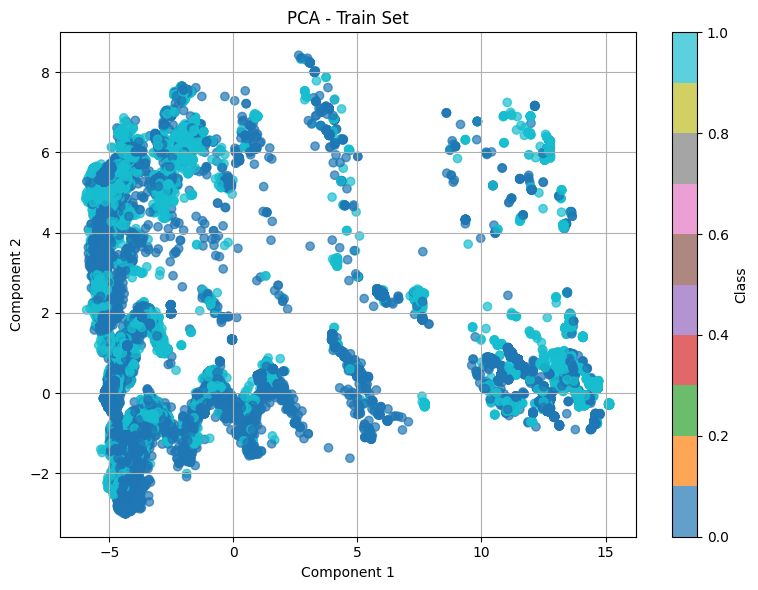

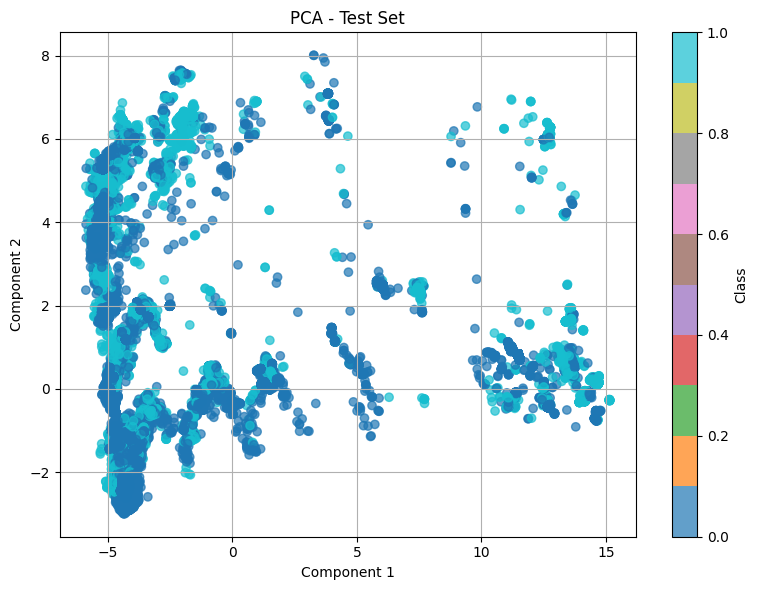

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load the embeddings from the .npz file
data = np.load('custom_data.npz')
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

def plot_2d(X, y, title, method='PCA'):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', alpha=0.7)
    plt.title(f'{method} - {title}')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.colorbar(scatter, label='Class')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

plot_2d(X_train_pca, y_train, 'Train Set', method='PCA')
plot_2d(X_test_pca, y_test, 'Test Set', method='PCA')

# t-SNE (can take longer on large datasets)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_train_tsne = tsne.fit_transform(X_train)
X_test_tsne = tsne.fit_transform(X_test)

plot_2d(X_train_tsne, y_train, 'Train Set', method='t-SNE')
plot_2d(X_test_tsne, y_test, 'Test Set', method='t-SNE')


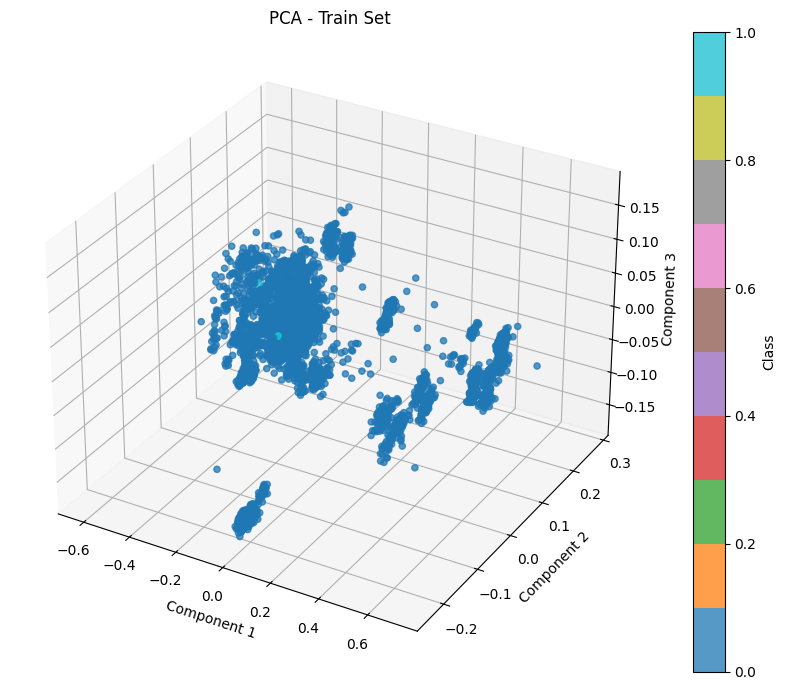

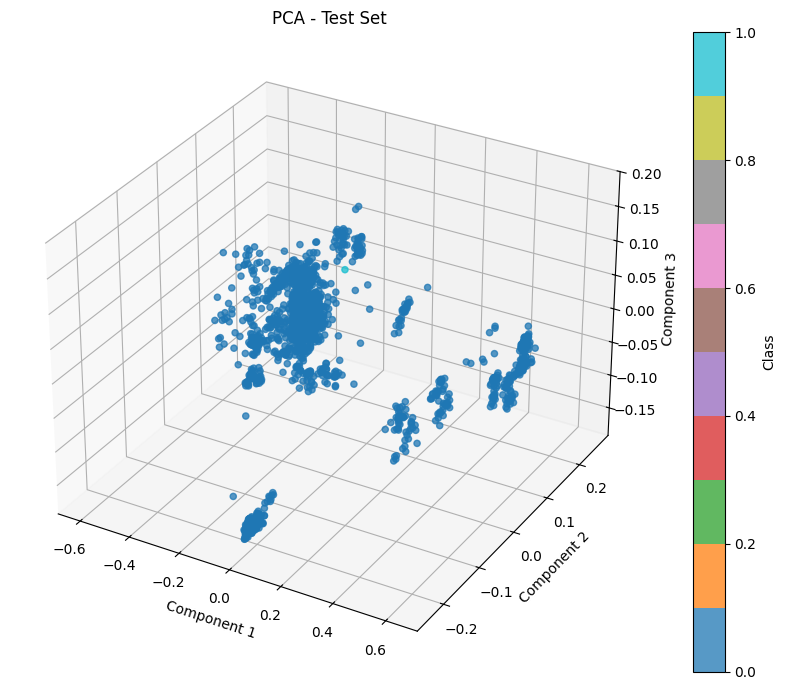

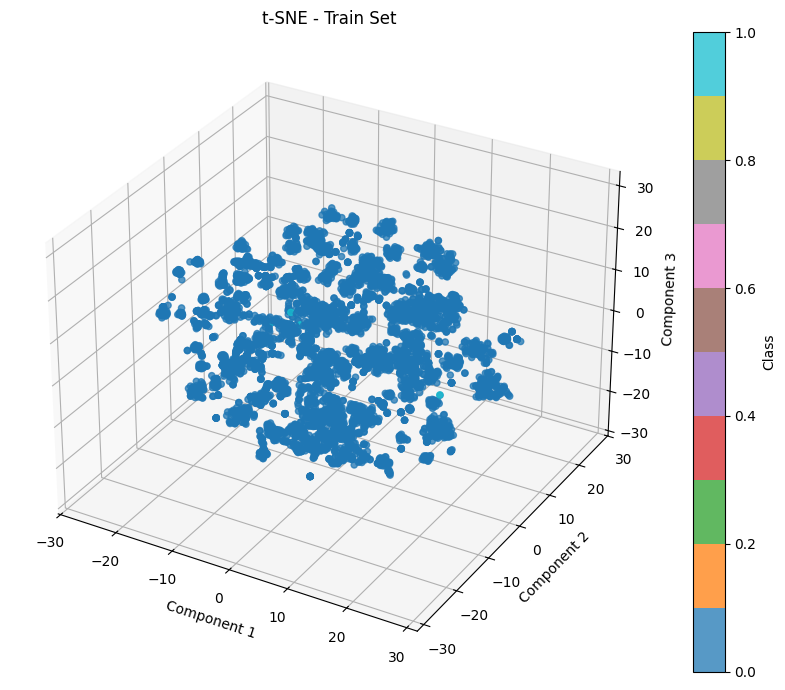

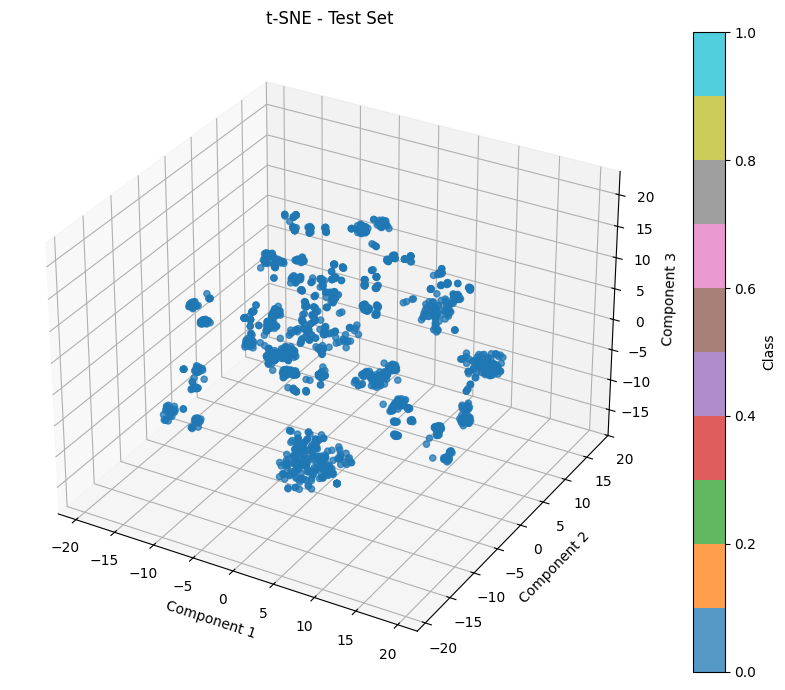

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

# Load your data
data = np.load('custom_data.npz')
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

# Define colors for binary classes
colors = ['red', 'blue']
labels = ['Class 0', 'Class 1']

def plot_3d_binary(X, y, title, method='PCA'):
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    for class_value in [0, 1]:
        idx = (y == class_value)
        ax.scatter(X[idx, 0], X[idx, 1], X[idx, 2], 
                   c=colors[class_value], label=labels[class_value], alpha=0.7, edgecolors='w', s=60)
    
    ax.set_title(f'{method} - {title}')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    ax.legend()
    plt.tight_layout()
    plt.show()

# PCA 3D
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

plot_3d_binary(X_train_pca, y_train, 'Train Set', method='PCA')
plot_3d_binary(X_test_pca, y_test, 'Test Set', method='PCA')

# t-SNE 3D
tsne = TSNE(n_components=3, random_state=42, perplexity=30, n_iter=1000)
X_train_tsne = tsne.fit_transform(X_train)
X_test_tsne = tsne.fit_transform(X_test)

plot_3d_binary(X_train_tsne, y_train, 'Train Set', method='t-SNE')
plot_3d_binary(X_test_tsne, y_test, 'Test Set', method='t-SNE')
